# Демонстрация возможности использования модуля в ноутбуке.

Модуль разрабатывался с прицелом на использование его функций в ноутбуке, 

в этом ноутбуке приведены примеры использования функций для решения тех задач, для которых эти функции разрабатывались.

In [1]:
import pq_tool as pqt

## Инициализация: создания базы метаданных

Перед началом работы с функциями модуля необходимо создать базу метаданных для паркет-файла. 

Это делает ячейка ниже, база данных создаётся в файле, являющимся вторым параметром вызова функции.

In [2]:
pqt.prepMeta(
    "/home/mk/mk_win/Documents/28.Arrow/data/tpcds_10g.parquet/store_sales.parquet", # работаем с файлом
    "/tmp/demo_otf.duckdb", # база данных создаётся в этом файле
    "", # ключ для S3 - оставляем пустым для файла
    "" # секрет для S3 - аналогично пуст для файла
)

## График взаимного расположения частей паркет файла

Здесь и далее первым параметром является имя файла с базой метаданных

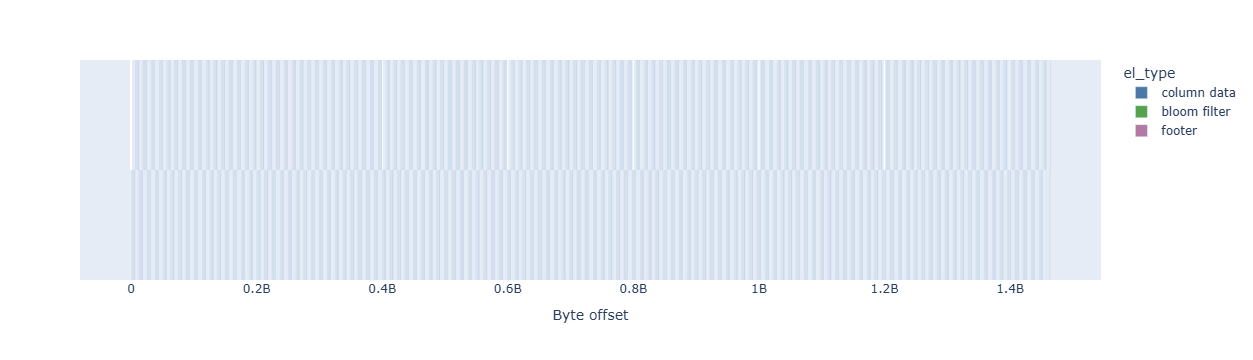

In [3]:
pqt.prepChart("/tmp/demo_otf.duckdb")

## Статистика по колонке

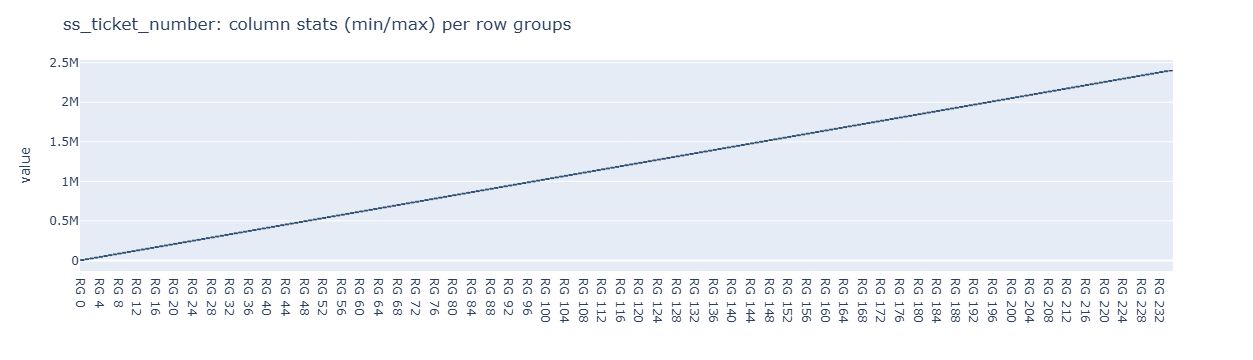

In [4]:
pqt.prepColChart("/tmp/demo_otf.duckdb","ss_ticket_number","en")

## Общая информация о файле

In [5]:
pqt.prepOverview(f"/tmp/demo_otf.duckdb","en")

[['General info',
  [('filename',
    '/home/mk/mk_win/Documents/28.Arrow/data/tpcds_10g.parquet/store_sales.parquet'),
   ('rows', '28 800 991'),
   ('row groups', 235),
   ('file size', '1 463 436 232 bytes'),
   ('compressions', "['SNAPPY']")]],
 ['Row Groups info',
  [('1 row groups have', '47 071 rows'),
   ('234 row groups have', '122 880 rows')]],
 ['Encodings used',
  [('PLAIN',
    'ss_addr_sk, ss_cdemo_sk, ss_coupon_amt, ss_customer_sk, ss_ext_discount_amt, ss_ext_list_price, ss_ext_sales_price, ss_ext_tax, ss_ext_wholesale_cost, ss_item_sk, ss_list_price, ss_net_paid, ss_net_paid_inc_tax, ss_net_profit, ss_sales_price, ss_sold_time_sk, ss_ticket_number, ss_wholesale_cost'),
   ('RLE_DICTIONARY',
    'ss_addr_sk, ss_cdemo_sk, ss_customer_sk, ss_hdemo_sk, ss_promo_sk, ss_quantity, ss_sold_date_sk, ss_sold_time_sk, ss_store_sk, ss_ticket_number')]],
 ['Bloom filter created',
  [('for columns',
    'ss_addr_sk, ss_cdemo_sk, ss_customer_sk, ss_hdemo_sk, ss_promo_sk, ss_quantity, 

## Показать статистику групп строк

In [6]:
pqt.prepRowGroupStats(f"/tmp/demo_otf.duckdb","en","ss_ticket_number",0)

{'name': ('value', 'Meta column description'),
 'path_in_schema': ('ss_ticket_number', 'Column name'),
 'column_id': (np.int64(9), 'column_id'),
 'type': ('INT32', 'type'),
 'num_values': (np.int64(122880), 'num_values'),
 'stats_min_value': ('1', 'stats_min_value'),
 'stats_max_value': ('10196', 'stats_max_value'),
 'stats_null_count': (np.int64(0), 'stats_null_count'),
 'stats_distinct_count': (<NA>, 'stats_distinct_count'),
 'encodings': ('PLAIN', 'encodings'),
 'compression': ('SNAPPY', 'compression'),
 'index_page_offset': (<NA>, 'index_page_offset'),
 'bloom_filter_offset': (<NA>, 'bloom_filter_offset'),
 'bloom_filter_length': (<NA>, 'bloom_filter_length'),
 'data_page_offset': (np.int64(1095288), 'data_page_offset'),
 'dictionary_page_offset': (<NA>, 'dictionary_page_offset'),
 'total_compressed_size': (np.int64(71458), 'total_compressed_size')}

## Проверить bloom фильтр

In [7]:
pqt.probeBloomFilter(f"/tmp/demo_otf.duckdb","en","ss_store_sk",0)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'No row groups will be excluded'